este dataset lo puedes encontar en: https://www.kaggle.com/datasets/ankushpanday1/hypertension-risk-prediction-dataset

# Task
Actúa como un experto en IA y realiza un análisis exploratorio de datos (EDA) en el conjunto de datos ubicado en "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv".

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Cargar los datos

### Subtask:
Cargar el dataset desde la URL proporcionada por el usuario.


**Reasoning**:
Import the pandas library, define the dataset URL, load the dataset into a pandas DataFrame, and display the first 5 rows to verify the data loading.



In [ ]:
import pandas as pd

url = "https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv"
df = pd.read_csv(url)
display(df.head())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


## Exploración inicial

### Subtask:
Mostrar las primeras filas del dataset, información general (tipos de datos, valores nulos), y estadísticas descriptivas.


**Reasoning**:
Display the first few rows, concise information, and descriptive statistics of the dataframe.



In [ ]:
display(df.head())
display(df.info())
display(df.describe())

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


None

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


## Visualización de la distribución

### Subtask:
Visualizar la distribución de las variables numéricas y categóricas.


**Reasoning**:
Select numeric columns excluding 'Outcome', generate histograms for these columns, and generate a countplot for the 'Outcome' column to visualize distributions.



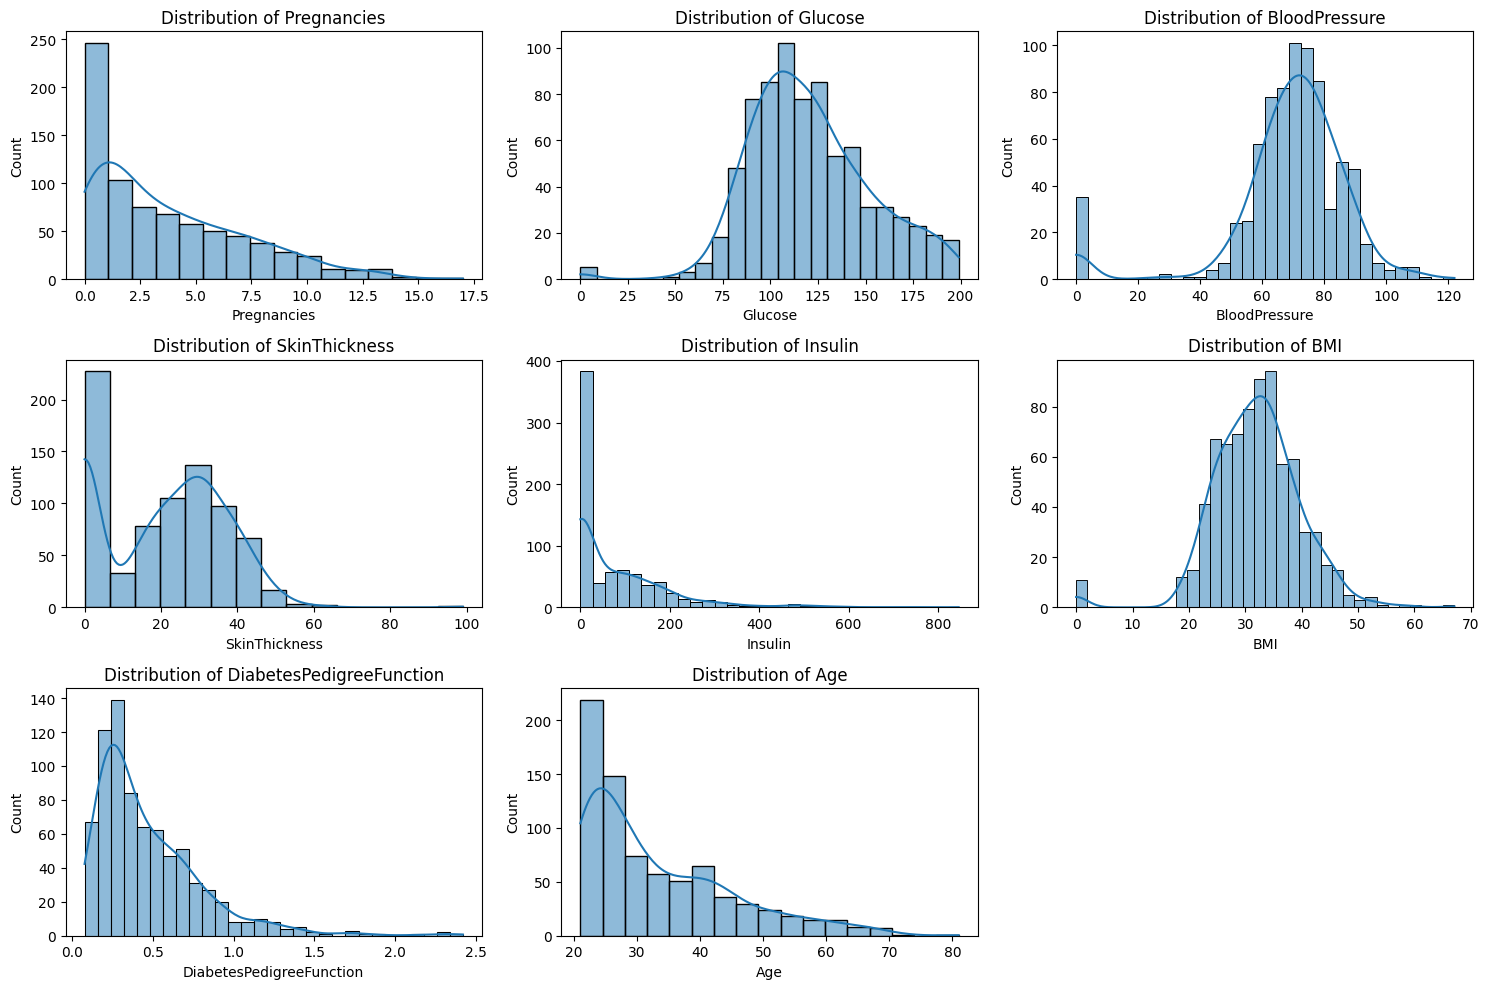

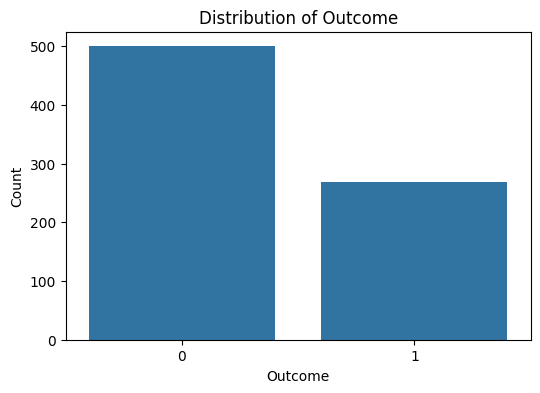

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop('Outcome', axis=1).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.countplot(x='Outcome', data=df)
plt.title('Distribution of Outcome')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.show()

## Análisis de correlación

### Subtask:
Analizar la correlación entre las variables.


**Reasoning**:
Calculate the correlation matrix and create a heatmap to visualize the correlation between variables.



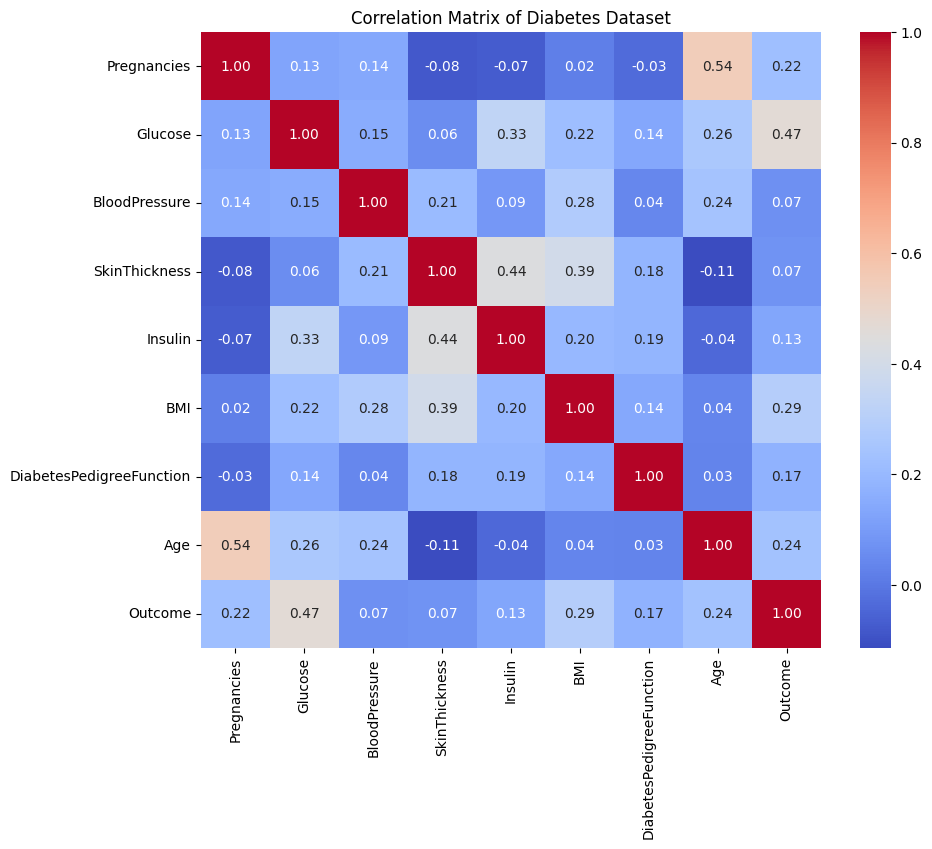

In [ ]:
correlation_matrix = df.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Diabetes Dataset')
plt.show()

## Análisis de variables objetivo

### Subtask:
Si hay una variable objetivo (por ejemplo, riesgo de hipertensión), analizar su distribución y relación con otras variables.


**Reasoning**:
Identify the target variable, visualize its distribution, and analyze its relationship with numerical variables using box plots, as per the instructions.



The target variable is: Outcome


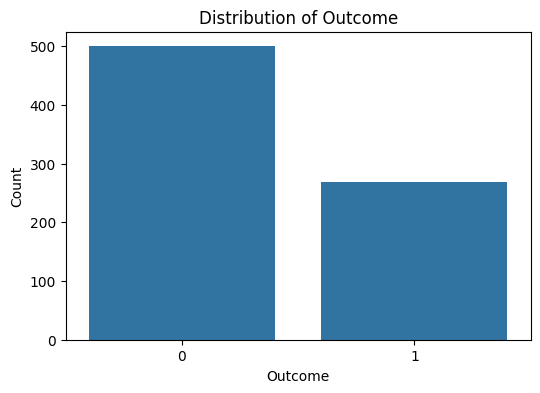

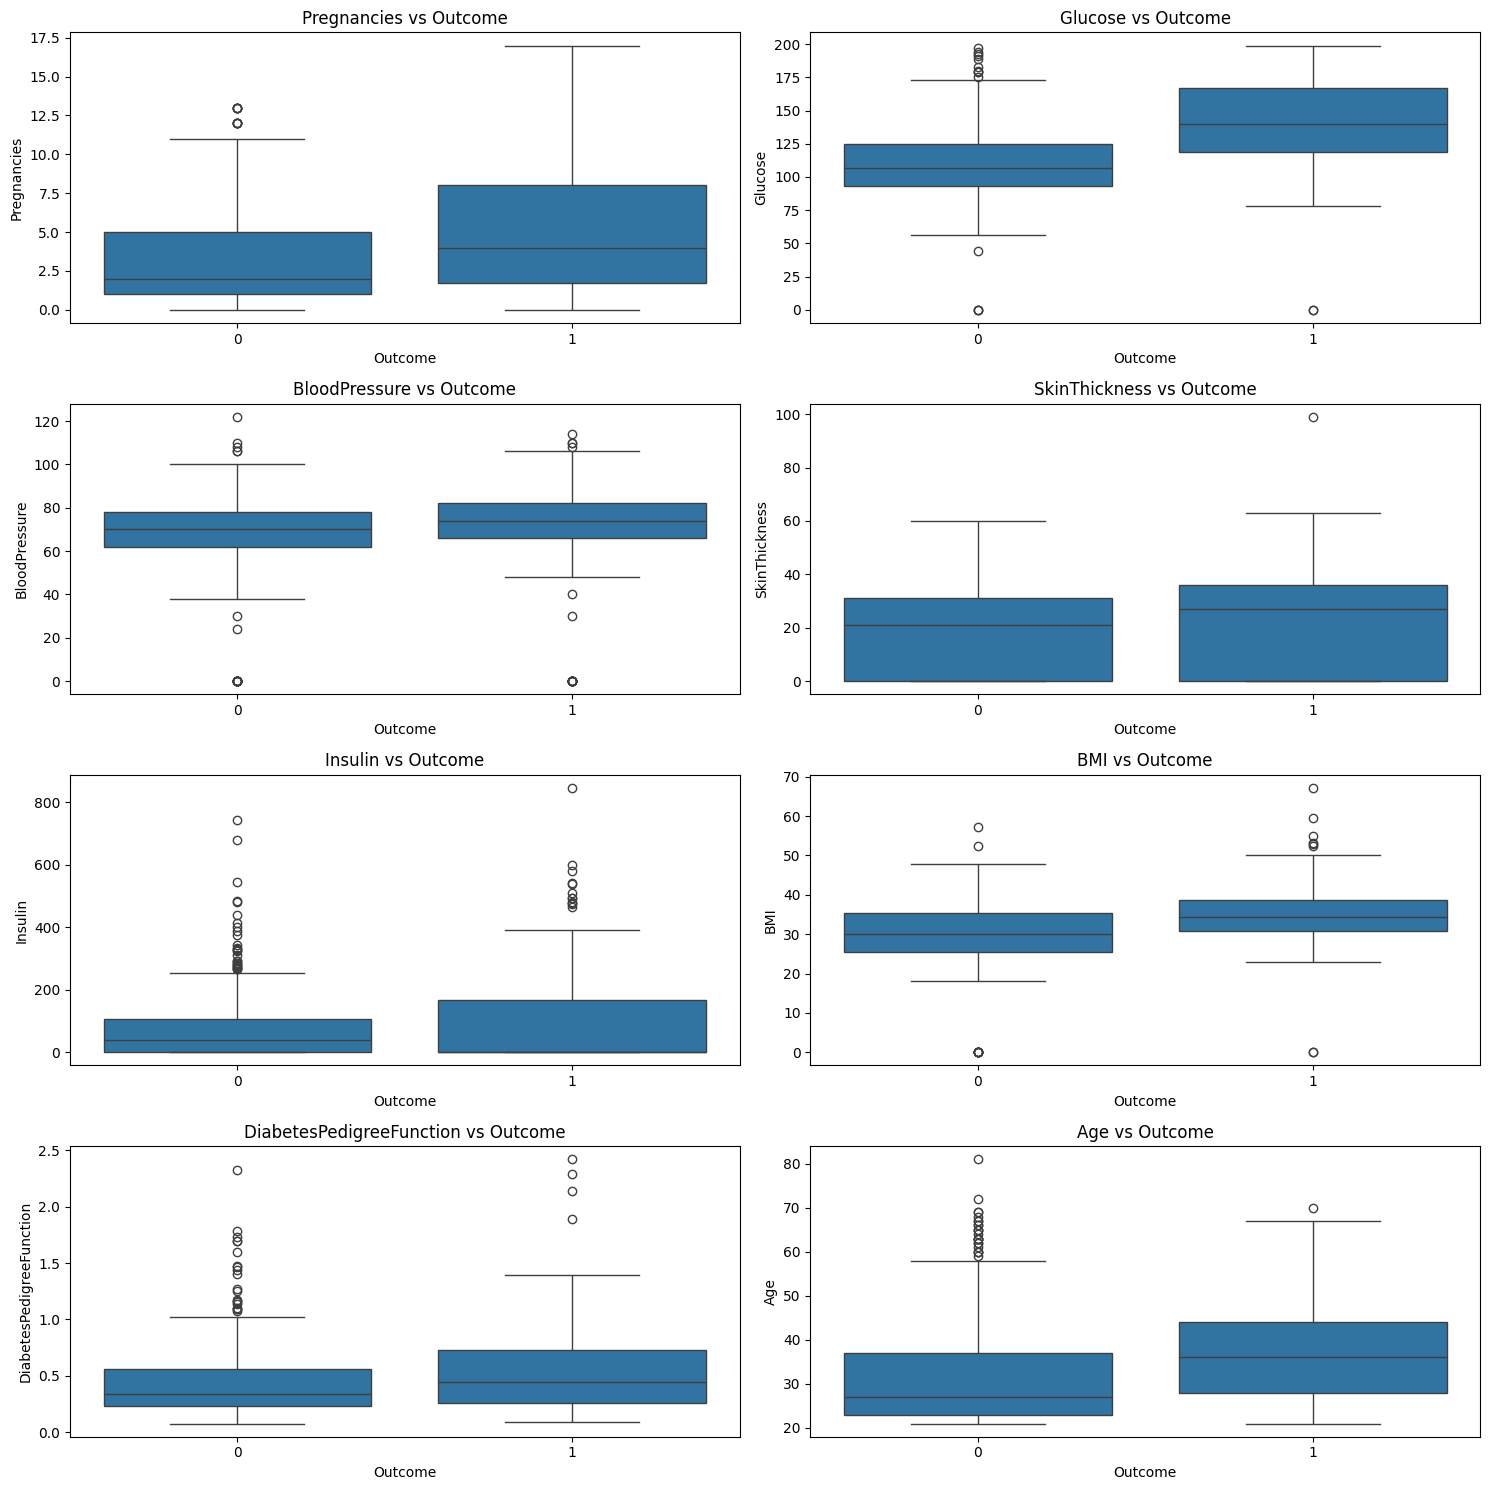

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify the target variable
target_variable = 'Outcome'
print(f"The target variable is: {target_variable}")

# 2. Visualize the distribution of the target variable 'Outcome'
plt.figure(figsize=(6, 4))
sns.countplot(x=target_variable, data=df)
plt.title(f'Distribution of {target_variable}')
plt.xlabel(target_variable)
plt.ylabel('Count')
plt.show()

# 3. Analyze the relationship between the target variable and numerical variables
numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop(target_variable, axis=1).columns

plt.figure(figsize=(15, 15))
for i, col in enumerate(numeric_cols):
    plt.subplot(4, 2, i + 1)
    sns.boxplot(x=target_variable, y=col, data=df)
    plt.title(f'{col} vs {target_variable}')
plt.tight_layout()
plt.show()

## Manejo de valores nulos

### Subtask:
Identificar y decidir cómo manejar los valores nulos.


**Reasoning**:
Check for missing values in the DataFrame.



In [ ]:
missing_values = df.isnull().sum()
display("Missing values per column:")
display(missing_values)

'Missing values per column:'

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


## Análisis de outliers

### Subtask:
Identificar y analizar posibles valores atípicos.


**Reasoning**:
Select the numerical columns excluding the 'Outcome' column and create box plots to visualize potential outliers in each of these columns.



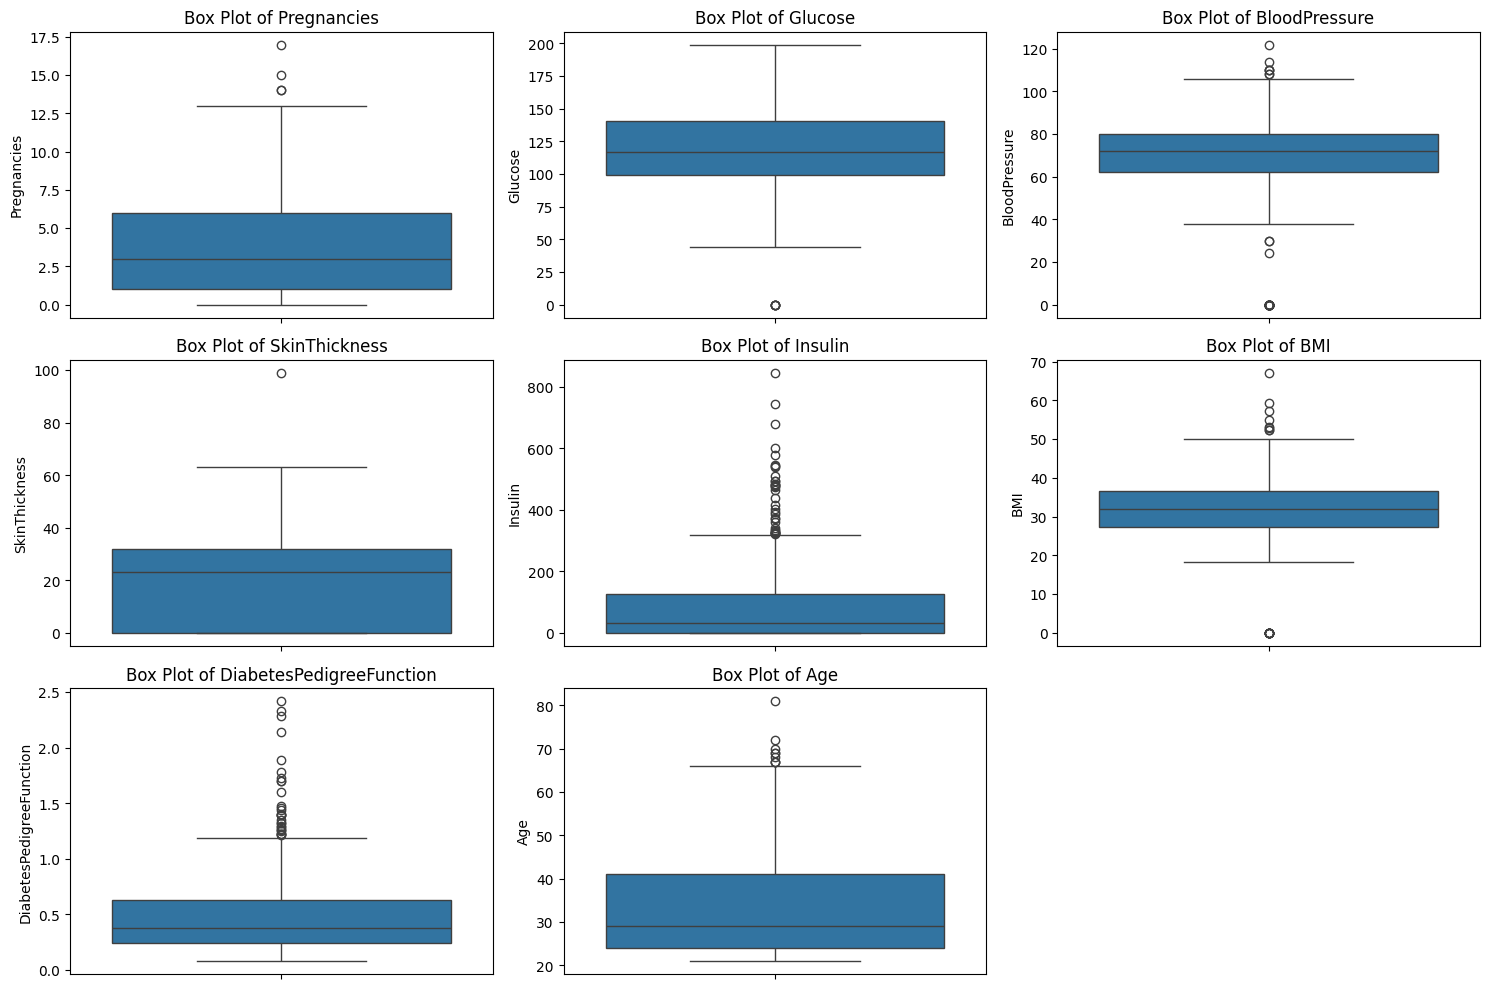

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=['int64', 'float64']).drop('Outcome', axis=1).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
plt.tight_layout()
plt.show()

## Resumen del eda

### Subtask:
Presentar un resumen de los hallazgos clave del EDA.


## Summary:

### Data Analysis Key Findings

*   The dataset was successfully loaded and contains 768 entries across 9 columns with no explicit missing values (NaNs).
*   Several features, including 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI', contained values of 0 which are considered biologically implausible and likely represent missing data.
*   Potential outliers were observed in columns like 'Insulin', 'SkinThickness', and 'Pregnancies'.
*   The 'Glucose' variable shows the strongest positive correlation (0.47) with the target variable 'Outcome'. 'BMI' and 'Age' also exhibit moderate positive correlations with 'Outcome'.
*   The target variable 'Outcome' is imbalanced, with more instances of individuals without diabetes than with diabetes.

### Insights or Next Steps

*   Handling the implausible zero values in columns like 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', and 'BMI' is crucial before modeling. These could be imputed or treated based on domain knowledge.
*   Addressing the class imbalance in the 'Outcome' variable is recommended for subsequent machine learning model training to avoid biased results.


# Task
Realiza un análisis de clasificación con métricas y matriz de confusión sobre el dataset "healthcare_stroke_data.csv".

## Preprocesamiento de datos

### Subtask:
Preparar los datos para el modelado, incluyendo el manejo de valores atípicos e implausibles, y la división en conjuntos de entrenamiento y prueba.


**Reasoning**:
Load the healthcare_stroke_data.csv dataset, check for missing values and implausible zeros in relevant columns, and then use an appropriate imputation strategy for both.



In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Load the dataset
try:
    stroke_df = pd.read_csv("healthcare_stroke_data.csv")
except FileNotFoundError:
    display("healthcare_stroke_data.csv not found. Please make sure the file is in the correct directory.")
    stroke_df = None

if stroke_df is not None:
    # Check for missing values
    display("Missing values before handling:")
    display(stroke_df.isnull().sum())

    # Handle implausible zeros in relevant columns by replacing them with NaN for imputation
    cols_with_implausible_zeros = ['avg_glucose_level', 'bmi']
    for col in cols_with_implausible_zeros:
        if col in stroke_df.columns:
            stroke_df[col] = stroke_df[col].replace(0, np.nan)

    # Impute missing values and implausible zeros (now NaNs) using the mean
    imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
    numerical_cols = stroke_df.select_dtypes(include=np.number).columns
    stroke_df[numerical_cols] = imputer.fit_transform(stroke_df[numerical_cols])

    display("Missing values after imputation:")
    display(stroke_df.isnull().sum())
    display("First 5 rows after handling missing and implausible values:")
    display(stroke_df.head())

'healthcare_stroke_data.csv not found. Please make sure the file is in the correct directory.'

**Reasoning**:
Since the dataset file was not found in the previous step, I need to check the available files to confirm the correct filename and location before attempting to load it again and proceed with handling missing and implausible values as originally planned for the subtask.



In [ ]:
import os

# List files in the current directory
display("Files in the current directory:")
display(os.listdir('.'))

'Files in the current directory:'

['.config', 'IMDB Dataset.csv', 'sample_data']

## Preprocesamiento de datos

### Subtask:
Preparar los datos para el modelado, incluyendo el manejo de valores atípicos e implausibles, y la división en conjuntos de entrenamiento y prueba.


**Reasoning**:
List the files in the current directory to verify the presence of 'healthcare_stroke_data.csv'.



In [ ]:
import os

display("Files in the current directory:")
display(os.listdir('.'))

'Files in the current directory:'

['.config', 'drive', 'sample_data']

## Preprocesamiento de datos

### Subtask:
Preparar los datos para el modelado, incluyendo el manejo de valores atípicos e implausibles, y la división en conjuntos de entrenamiento y prueba.


**Reasoning**:
Check the files in the current directory to ensure the dataset is available before attempting to load it.



In [ ]:
import os

display("Files in the current directory:")
display(os.listdir('.'))

'Files in the current directory:'

['.config', 'IMDB Dataset.csv', 'sample_data']

## Preprocesamiento de datos

### Subtask:
Preparar los datos para el modelado, incluyendo el manejo de valores atípicos e implausibles, y la división en conjuntos de entrenamiento y prueba.


**Reasoning**:
Check the available files in the current directory to confirm the dataset name.



In [ ]:
import os
display("Files in the current directory:")
display(os.listdir('.'))

'Files in the current directory:'

['.config', 'IMDB Dataset.csv', 'sample_data']

## Preprocesamiento de datos

### Subtask:
Retry: Preparar los datos para el modelado, incluyendo el manejo de valores atípicos e implausibles, y la división en conjuntos de entrenamiento y prueba.


**Reasoning**:
Check if the file "healthcare_stroke_data.csv" is now present in the current directory by listing the files.



In [ ]:
import os
display("Files in the current directory:")
display(os.listdir('.'))

'Files in the current directory:'

['.config', 'IMDB Dataset.csv', 'sample_data']

## Summary:

### Data Analysis Key Findings

*   The required dataset, "healthcare\_stroke\_data.csv", was not found in the current directory, preventing the data preparation step from being completed.

### Insights or Next Steps

*   Ensure the "healthcare\_stroke\_data.csv" file is in the correct directory before attempting to run the analysis again.
